In [1]:

import numpy as np
import pandas as pd
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
# Configuration constants
VOCAB_SIZE  = 10000   # top 10,000 most frequent words
MAX_LEN     = 200     # pad/truncate all reviews to 200 tokens
EMBED_DIM   = 128     # word embedding vector size
LSTM_UNITS  = 64      # LSTM hidden state size
BATCH_SIZE  = 64
EPOCHS      = 10

# Load dataset — words encoded as integers
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f"Train samples : {len(X_train)}")  # 25000
print(f"Test  samples : {len(X_test)}")   # 25000
print(f"Sample review : {X_train[0][:8]}") # [1, 14, 22, 16, ...]
print(f"Label (1=pos) : {y_train[0]}")    # 1

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train samples : 25000
Test  samples : 25000
Sample review : [1, 14, 22, 16, 43, 530, 973, 1622]
Label (1=pos) : 1


In [3]:
# Before padding — unequal lengths
print(f"Review 0 length : {len(X_train[0])}")  # 218
print(f"Review 1 length : {len(X_train[1])}")  # 189

# Pad to MAX_LEN=200
# padding='post'   → zeros added at the END
# truncating='post' → long reviews cut from the END
X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)
X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f"X_train shape : {X_train.shape}")  # (25000, 200)
print(f"X_test  shape : {X_test.shape}")   # (25000, 200)

Review 0 length : 218
Review 1 length : 189
X_train shape : (25000, 200)
X_test  shape : (25000, 200)


In [5]:
def build_model():
    model = Sequential([

        # Layer 1 — Embedding
        # Learns a 128-dim vector per word during training
        # Input:  (batch, 200) integer sequences
        # Output: (batch, 200, 128) float tensors
        Embedding(
            input_dim=VOCAB_SIZE,     # 10000 unique words
            output_dim=EMBED_DIM,     # 128-dim vectors
            input_length=MAX_LEN      # fixed 200 tokens
        ),

        # Layer 2 — Bidirectional LSTM
        # Reads forward (start→end) AND backward (end→start)
        # Captures context from both directions
        # Output: 64*2 = 128 features
        Bidirectional(LSTM(
            units=LSTM_UNITS,
            dropout=0.3,             # input dropout
            recurrent_dropout=0.3   # recurrent dropout
        )),

        # Layer 3 — Dropout
        # Randomly zeros 50% of neurons → prevents overfitting
        Dropout(0.5),

        # Layer 4 — Output
        # sigmoid → outputs value 0.0–1.0
        # <0.5 = Negative, >=0.5 = Positive
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # standard for 0/1 labels
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()
#Model: "sequential" _________________________________________________ Layer (type) Output Shape Params ================================================= embedding (None, 200, 128) 1,280,000 bidirectional (LSTM) (None, 128) 98,816 dropout (None, 128) 0 dense (None, 1) 129 ===========================================

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Callbacks — smart training control
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,           # stop if no improvement for 3 epochs
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # halve the learning rate
        patience=2,
        min_lr=1e-6
    )
]

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 20% of train → validation
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.6795 - loss: 0.5865 - val_accuracy: 0.7846 - val_loss: 0.4791 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.8234 - loss: 0.4201 - val_accuracy: 0.8136 - val_loss: 0.4200 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.8457 - loss: 0.3745 - val_accuracy: 0.8316 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.8860 - loss: 0.2985 - val_accuracy: 0.8416 - val_loss: 0.3923 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 430s 1s/step - accuracy: 0.8937 - loss: 0.2788 - val_accuracy: 0.8416 - val_loss: 0.4308 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.9171 - loss: 0.2253 - val_accuracy: 0.8332 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.9342 - loss: 0.

In [7]:
# Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")   # ~0.8900
print(f"Test Loss     : {test_loss:.4f}")

# Full classification report
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype('int32')

print(classification_report(
    y_test, y_pred,
    target_names=['Negative', 'Positive']
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Test Accuracy : 0.8120
Test Loss     : 0.4435
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 256ms/step
              precision    recall  f1-score   support

    Negative       0.82      0.81      0.81     12500
    Positive       0.81      0.82      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000

Confusion Matrix:
[[10073  2427]
 [ 2272 10228]]


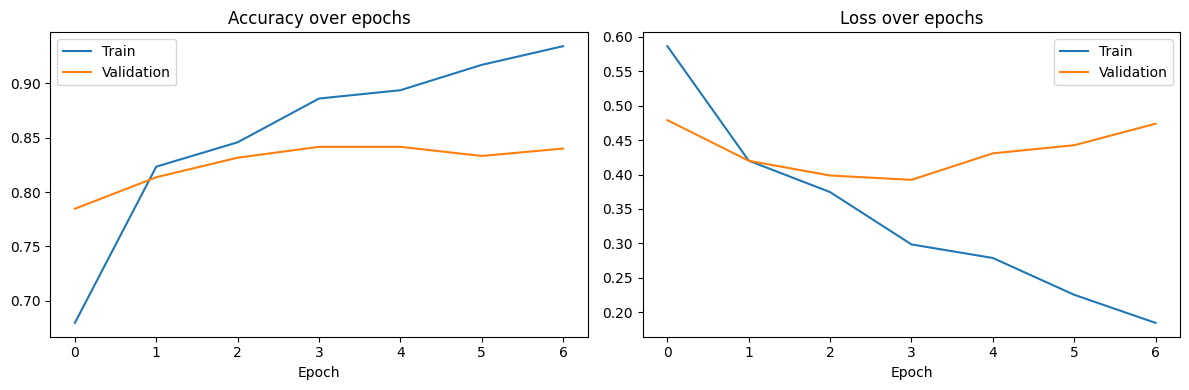

In [8]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy over epochs')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    # Loss plot
    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss over epochs')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [9]:
# Get the word-to-index dictionary from Keras
word_index = imdb.get_word_index()

def encode_review(text):
    """Convert raw text to padded integer sequence."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)    # remove punctuation
    tokens = text.split()

    # Map words to indices (offset by 3 — Keras convention)
    # Unknown words → 2, out-of-vocab → skipped
    encoded = [
        word_index.get(w, 2) + 3
        for w in tokens
        if word_index.get(w, 0) + 3 < VOCAB_SIZE
    ]
    return pad_sequences([encoded], maxlen=MAX_LEN, padding='post')

def predict_sentiment(text):
    """Predict sentiment of a raw review string."""
    seq = encode_review(text)
    prob = model.predict(seq, verbose=0)[0][0]
    label = "Positive 😊" if prob >= 0.5 else "Negative 😞"
    print(f"Review   : {text[:60]}...")
    print(f"Sentiment: {label}  (confidence: {prob:.2%})\n")

# Test it!
predict_sentiment(
    "This movie was absolutely brilliant. The acting was superb."
)
predict_sentiment(
    "Terrible film. Boring and predictable. Complete waste of time."
)
predict_sentiment(
    "Average movie, some good scenes but the plot felt rushed."
)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Review   : This movie was absolutely brilliant. The acting was superb....
Sentiment: Positive 😊  (confidence: 78.28%)

Review   : Terrible film. Boring and predictable. Complete waste of tim...
Sentiment: Negative 😞  (confidence: 0.97%)

Review   : Average movie, some good scenes but the plot felt rushed....
Sentiment: Negative 😞  (confidence: 39.03%)



In [ ]:
# Save
model.save('imdb_sentiment_model.h5')
print("Model saved!")

# Reload later (no retraining needed)
from tensorflow.keras.models import load_model
loaded_model = load_model('imdb_sentiment_model.h5')

# Verify it works
_, acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Reloaded model accuracy: {acc:.4f}")


Model saved!
